# Spotify Müzik Veri Seti Analiz Raporu

**Hazırlayan:** Tuğba Nar   
**Tarih:** Haziran 2026  
**Ders:** Veri Analizinde Bilgisayar Programlama 2  

## Genel Bakış ve Amaç
Bu raporda, popüler müzik platformu Spotify'dan alınan ve 2586 şarkı içeren kapsamlı bir veri seti analiz edilmiştir. Analizin amacı; şarkı sürelerinin dağılımını incelemek, en çok tercih edilen şarkı türlerini belirlemek, sanatçı bazlı üretim performanslarını görmek ve içeriklerdeki argo kullanım oranlarını tanımsal istatistikler ve grafikler yardımıyla ortaya koymaktır.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("spotify excel.xlsx")

df.head()

,ALBÜM ADI,SANATÇI,ÇIKIŞ TARİHİ,ŞARKI ADI,ŞARKI SÜRESİ(SANİYE),ŞARKI SIRASI,ARGO VAR MI?,ŞARKI TÜRÜ
0,ARIRANG,BTS,2026-03-20 00:00:00,Body to Body,190,1,Hayır,K-POP
1,ARIRANG,BTS,2026-03-20 00:00:00,Hooligan,168,2,Hayır,K-POP
2,ARIRANG,BTS,2026-03-20 00:00:00,Aliens,181,3,Hayır,K-POP
3,ARIRANG,BTS,2026-03-20 00:00:00,FYA,170,4,Hayır,K-POP
4,ARIRANG,BTS,2026-03-20 00:00:00,2,98,5,Hayır,K-POP


In [23]:
df.shape

(2586, 8)

In [4]:
df.columns

Index(['ALBÜM ADI', 'SANATÇI', 'ÇIKIŞ TARİHİ', 'ŞARKI ADI',
       'ŞARKI SÜRESİ(SANİYE)', 'ŞARKI SIRASI', 'ARGO VAR MI?', 'ŞARKI TÜRÜ'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2586 entries, 0 to 2585
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ALBÜM ADI             2586 non-null   object
 1   SANATÇI               2586 non-null   object
 2   ÇIKIŞ TARİHİ          2586 non-null   object
 3   ŞARKI ADI             2586 non-null   object
 4   ŞARKI SÜRESİ(SANİYE)  2586 non-null   int64 
 5   ŞARKI SIRASI          2586 non-null   int64 
 6   ARGO VAR MI?          2586 non-null   object
 7   ŞARKI TÜRÜ            2586 non-null   object
dtypes: int64(2), object(6)
memory usage: 161.8+ KB


# Veri Setinin Tanıtımı

Bu çalışmada Spotify platformundan elde edilen bir müzik veri seti kullanılmıştır. Veri seti 2586 gözlem ve 8 değişkenden oluşmaktadır.

Veri setinde her bir şarkıya ait albüm adı, sanatçı bilgisi, yayın tarihi, şarkı adı, şarkı süresi, albüm içindeki sıra numarası, argo kullanım durumu ve müzik türü gibi değişkenler yer almaktadır. Bu bilgiler kullanılarak veri seti üzerinde çeşitli istatistiksel analizler gerçekleştirilmiştir.

In [6]:
df["ŞARKI TÜRÜ"].value_counts()

ŞARKI TÜRÜ
POP                  922
TRAP                 359
ARABESK              320
ALTERNATİF POP       174
ALTERNATİF ROCK      162
TÜRK HALK MÜZİĞİ      66
K-POP                 64
ROCK                  62
ELEKTRONİK POP        57
POP                   54
ANADOLU ROCK          43
R&B                   39
BEDROOM-POP           31
DANCE POP             30
DANCE-POP             27
PSYCHEDELİC ROCK      25
RAP                   24
LATİN TRAP            17
HİP HOP               16
SYNTH-POP             16
ARABESK POP           14
DRİLL                 12
TÜRK SANAT MÜZİĞİ     12
INDİE POP             12
ARABESK               10
ARABESK RAP            9
INDİE ROCK             9
Name: count, dtype: int64

## Tanımsal İstatistikler

Veri setindeki şarkı türlerinin dağılımı incelenmiştir.

In [1]:
df["ŞARKI TÜRÜ"].value_counts().head(10).plot(kind="bar")
plt.title("Şarkı Türlerine Göre Dağılım")
plt.xlabel("Şarkı Türü")
plt.ylabel("Şarkı Sayısı")
plt.show()

NameError: name 'df' is not defined

### Grafik  Yorumu

Grafiğe göre veri setinde en sık karşılaşılan müzik türünün Pop olduğu görülmektedir. Pop müziğini sırasıyla Trap ve Arabesk türleri takip etmektedir. Elde edilen bulgular, veri setinin ağırlıklı olarak geniş kitlelere hitap eden ve popüler müzik türlerinden oluştuğunu göstermektedir.

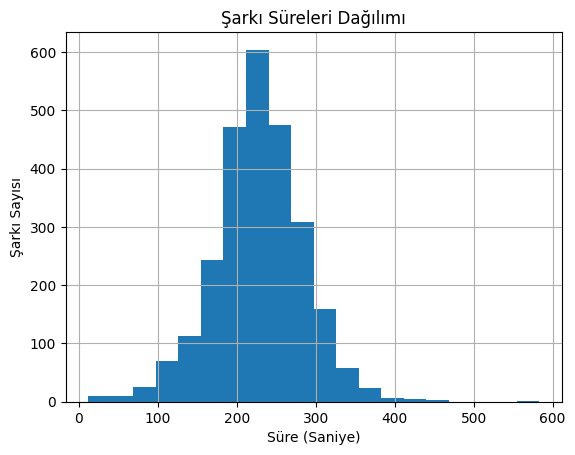

In [26]:
df["ŞARKI SÜRESİ(SANİYE)"].hist(bins=20)

plt.title("Şarkı Süreleri Dağılımı")
plt.xlabel("Süre (Saniye)")
plt.ylabel("Şarkı Sayısı")

plt.show()

### Grafik  Yorumu

Bu grafikte şarkı sürelerinin dağılımı gösterilmektedir. Şarkıların büyük bir kısmının belirli bir süre aralığında yoğunlaştığı görülmektedir. Çok kısa ve çok uzun süreli şarkılar daha az sayıdadır.

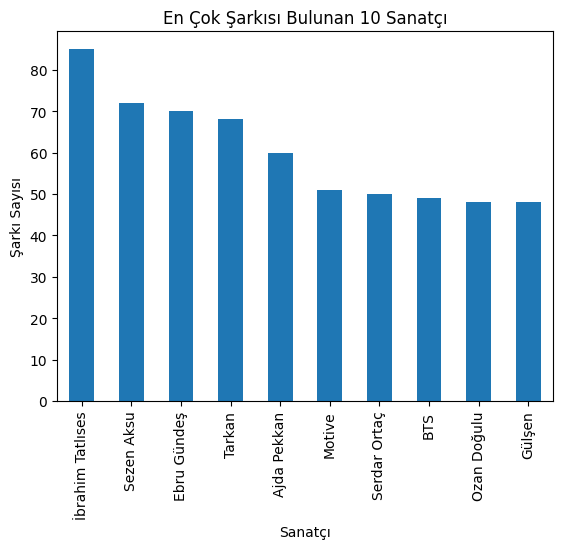

In [11]:
df["SANATÇI"].value_counts().head(10).plot(kind="bar")

plt.title("En Çok Şarkısı Bulunan 10 Sanatçı")
plt.xlabel("Sanatçı")
plt.ylabel("Şarkı Sayısı")

plt.show()

### Grafik Yorumu

Grafik incelendiğinde veri setinde en fazla şarkıya sahip sanatçının İbrahim Tatlıses olduğu görülmektedir. İbrahim Tatlıses'i Sezen Aksu, Ebru Gündeş ve Tarkan takip etmektedir. Veri setinde Türk müziğine ait sanatçıların ağırlıklı olduğu söylenebilir.

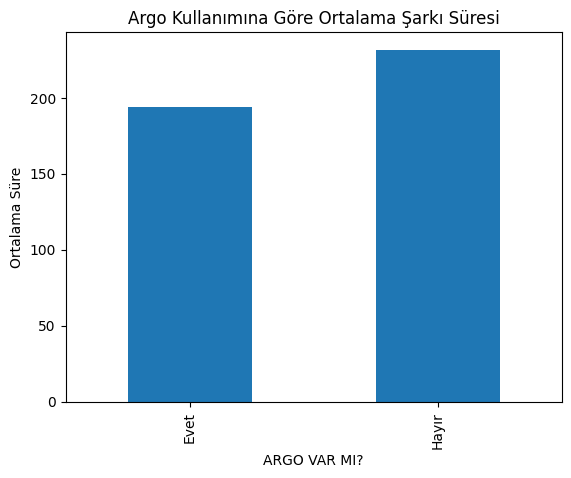

In [27]:
df.groupby("ARGO VAR MI?")["ŞARKI SÜRESİ(SANİYE)"].mean().plot(kind="bar")

plt.title("Argo Kullanımına Göre Ortalama Şarkı Süresi")
plt.ylabel("Ortalama Süre")
plt.show()

### Grafik Yorumu
Argo kullanım durumuna göre şarkı sürelerinin ortalaması analiz edilmiş ve argo içeren şarkıların, içermeyenlere kıyasla ortalama olarak daha kısa bir süreye sahip olduğu tespit edilmiştir. Argo barındıran eserlerin ortalama süresi 200 saniyenin altında kalırken, argo barındırmayan şarkıların ortalama süresi 230 saniye civarında seyretmektedir. Bu sonuç, argo içerikli müzik üretimlerinin genellikle daha kısa ve hızlı tempolu şarkı yapılarında yoğunlaştığı şeklinde yorumlanabilir.

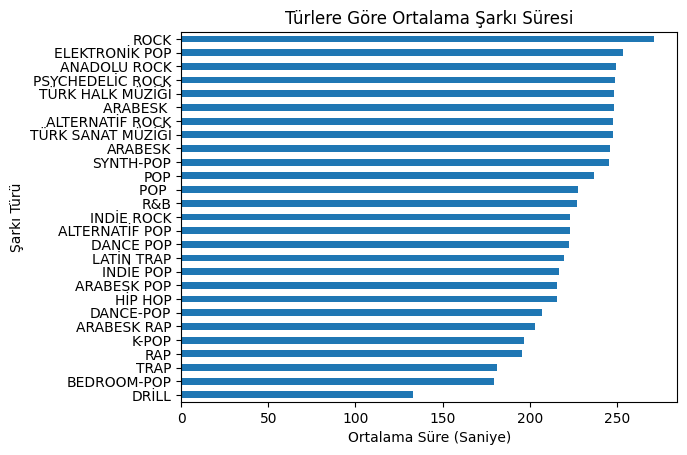

In [15]:
df.groupby("ŞARKI TÜRÜ")["ŞARKI SÜRESİ(SANİYE)"].mean().sort_values().plot(kind="barh")

plt.title("Türlere Göre Ortalama Şarkı Süresi")
plt.xlabel("Ortalama Süre (Saniye)")
plt.ylabel("Şarkı Türü")
plt.show()

### Grafik Yorumu
Grafiğe baktığımızda müzik türlerinin ortalama şarkı sürelerine göre küçükten büyüğe sıralandığını görüyoruz. En uzun ortalama süreye sahip tür net bir şekilde Rock iken, en kısa ortalama süreye sahip tür açık ara Drill olarak öne çıkıyor. Genel olarak rap türevleri (Drill, Trap, Rap) alt sıralarda, geleneksel ve rock tabanlı türler ise üst sıralarda yer alıyor.

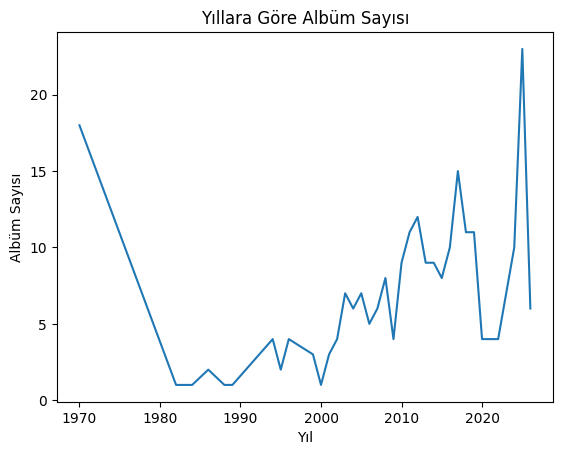

In [18]:
df["ÇIKIŞ TARİHİ"] = pd.to_datetime(df["ÇIKIŞ TARİHİ"])

df.groupby(df["ÇIKIŞ TARİHİ"].dt.year)["ALBÜM ADI"].nunique().plot(kind="line")

plt.title("Yıllara Göre Albüm Sayısı")
plt.xlabel("Yıl")
plt.ylabel("Albüm Sayısı")
plt.show()

### Grafik Yorumu
Veri setinde yer alan albümlerin çıkış yıllarına göre dağılımı incelendiğinde, 1970'lerden 2000'lerin başına kadar albüm sayısının oldukça düşük ve dalgalı bir seyir izlediği görülmektedir. Ancak 2000'li yıllardan itibaren, dijital müzik platformlarının yaygınlaşmasına paralel olarak albüm üretiminde belirgin bir artış trendi başlamıştır. Özellikle son yıllarda (2020 sonrası) albüm sayısının zirve noktasına ulaşması, veri setinin güncel müzik içeriklerine daha yoğun şekilde odaklandığını ve dijital çağdaki üretim hızının arttığını açıkça ortaya koymaktadır.

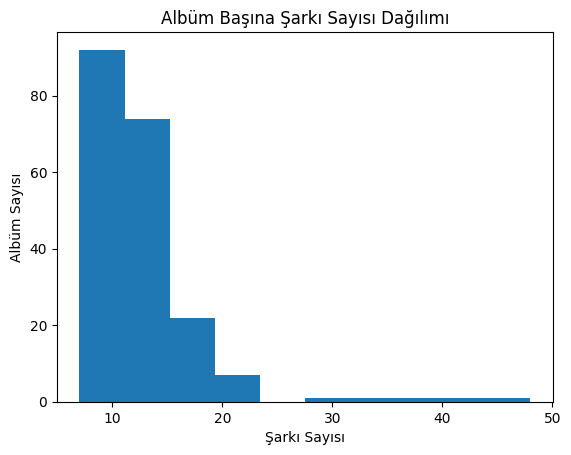

In [ ]:
album_counts = df["ALBÜM ADI"].value_counts()

album_counts.plot(kind="hist", bins=10)

plt.title("Albüm Başına Şarkı Sayısı Dağılımı")
plt.xlabel("Şarkı Sayısı")
plt.ylabel("Albüm Sayısı")

plt.show()

### Grafik Yorumu
Albümlerin şarkı sayılarına göre dağılımı incelendiğinde, büyük bir çoğunluğun 10 ila 15 şarkı arasında yoğunlaştığı görülmektedir. Şarkı sayısı 20'yi aşan albüm sayısı oldukça az olup, veri setindeki albüm üretim yapısının endüstri standartlarına paralel olarak belirli bir şarkı aralığında kümelendiğini göstermektedir.